# Titanic Dataset — Exploratory Data Analysis
**ZYNXIS AI/ML Internship — Month 1, Week 1 Deliverable**

**Dataset:** Titanic — Machine Learning from Disaster (public dataset, 891 passenger records)
**Goal:** Perform a full EDA — clean the data, handle missing values, and generate meaningful visualizations to understand what drove passenger survival.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv("titanic.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Initial Inspection
Before touching anything, look at structure, data types, and summary statistics.

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 2. Missing Values

Three columns have missing data:
- **Age** — 177 missing (~20%)
- **Cabin** — 687 missing (~77%)
- **Embarked** — 2 missing (~0.2%)


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


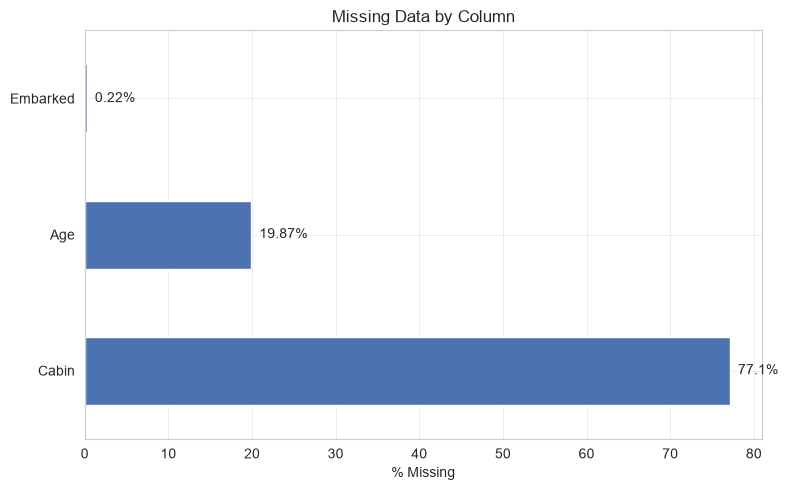

In [7]:
# Visualization 1: Missing data overview
fig, ax = plt.subplots(figsize=(8, 5))
missing_summary['missing_pct'].plot(kind='barh', color='#4C72B0', ax=ax)
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column')
for i, v in enumerate(missing_summary['missing_pct']):
    ax.text(v + 1, i, f"{v}%", va='center')
plt.tight_layout()
plt.savefig('missing_data.png', dpi=120)
plt.show()


## 3. Data Cleaning

**Decisions made:**
- **Age**: Impute missing values using the **median age within each (Pclass, Sex) group** rather than a single global median — age varies meaningfully by class and sex (e.g. 1st class passengers tended to be older).
- **Embarked**: Only 2 missing — fill with the **mode** (most common port).
- **Cabin**: 77% missing — too sparse to impute meaningfully. Instead of dropping it, convert it into a binary feature `HasCabin` (1 if a cabin number was recorded, 0 otherwise), since recording a cabin is itself informative (likely correlated with class/fare).
- **Dropped columns**: `PassengerId`, `Name`, `Ticket` — identifiers with no direct analytical value for this EDA.


In [8]:
df_clean = df.copy()

# Age: median by Pclass + Sex
df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Cabin -> HasCabin flag
df_clean['HasCabin'] = df_clean['Cabin'].notnull().astype(int)
df_clean.drop(columns=['Cabin'], inplace=True)

# Drop non-analytical identifiers
df_clean.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print(f"\nFinal shape: {df_clean.shape}")
df_clean.head()


Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
HasCabin    0
dtype: int64

Final shape: (891, 9)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0


## 4. Visualizations

### 4.1 Survival Rate by Sex

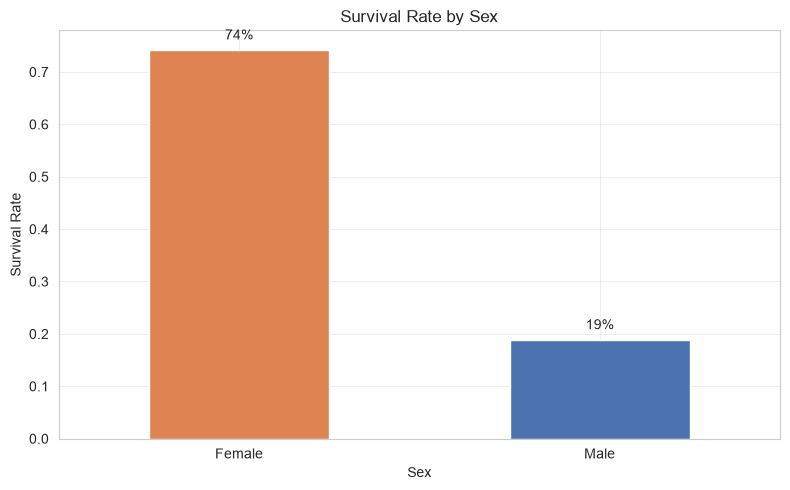

In [9]:
fig, ax = plt.subplots()
survival_by_sex = df_clean.groupby('Sex')['Survived'].mean()
survival_by_sex.plot(kind='bar', color=['#DD8452', '#4C72B0'], ax=ax)
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Sex')
ax.set_xticklabels(['Female', 'Male'], rotation=0)
for i, v in enumerate(survival_by_sex):
    ax.text(i, v + 0.02, f"{v:.0%}", ha='center')
plt.tight_layout()
plt.savefig('survival_by_sex.png', dpi=120)
plt.show()


### 4.2 Survival Rate by Passenger Class

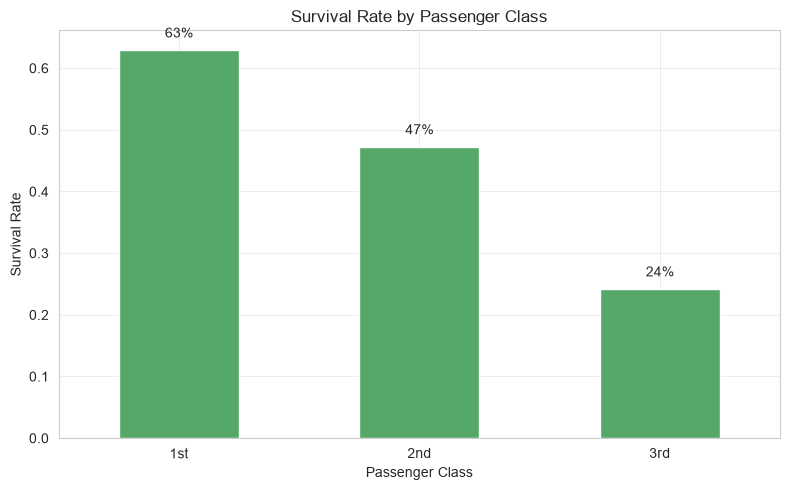

In [10]:
fig, ax = plt.subplots()
survival_by_class = df_clean.groupby('Pclass')['Survived'].mean()
survival_by_class.plot(kind='bar', color='#55A868', ax=ax)
ax.set_ylabel('Survival Rate')
ax.set_xlabel('Passenger Class')
ax.set_title('Survival Rate by Passenger Class')
ax.set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
for i, v in enumerate(survival_by_class):
    ax.text(i, v + 0.02, f"{v:.0%}", ha='center')
plt.tight_layout()
plt.savefig('survival_by_class.png', dpi=120)
plt.show()


### 4.3 Age Distribution: Survivors vs Non-Survivors

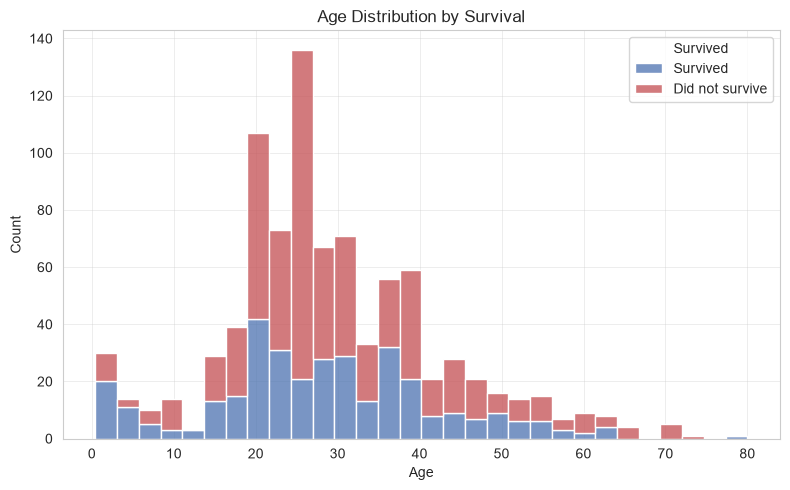

In [11]:
fig, ax = plt.subplots()
sns.histplot(data=df_clean, x='Age', hue='Survived', multiple='stack', bins=30,
             palette={0: '#C44E52', 1: '#4C72B0'}, ax=ax)
ax.set_title('Age Distribution by Survival')
ax.legend(title='Survived', labels=['Survived', 'Did not survive'])
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=120)
plt.show()


### 4.4 Fare Distribution by Class

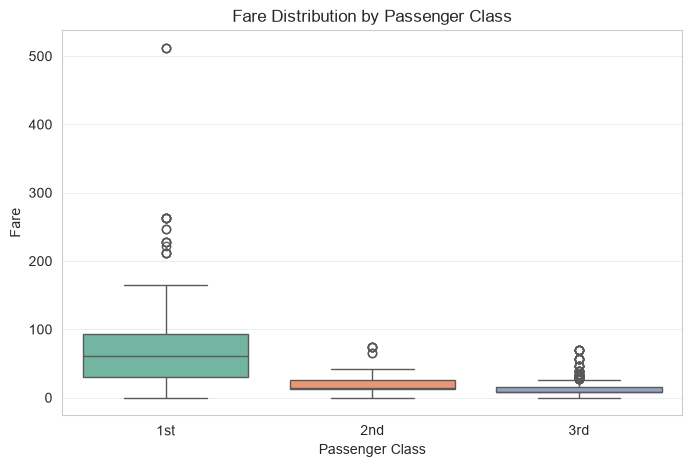

In [13]:
fig, ax = plt.subplots()
sns.boxplot(data=df_clean, x='Pclass', y='Fare', ax=ax, hue='Pclass', palette='Set2', legend=False)
ax.set_title('Fare Distribution by Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_xticks([0, 1, 2], ['1st', '2nd', '3rd'])
plt.show()

### 4.5 Correlation Heatmap (Numeric Features)

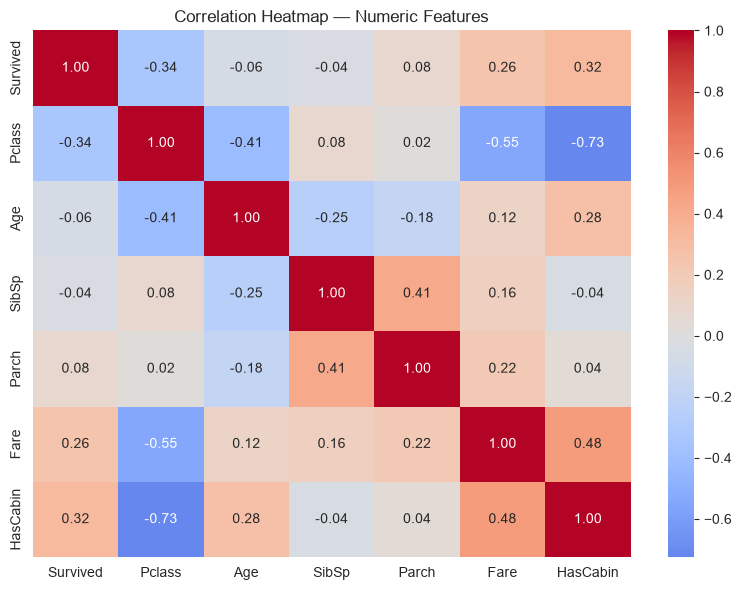

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
numeric_cols = df_clean.select_dtypes(include=[np.number])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()


### 4.6 Survival Rate by Family Size

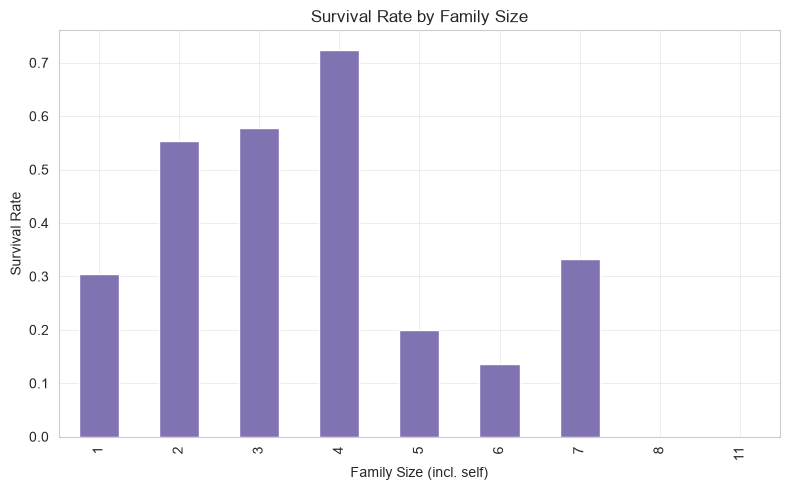

In [15]:
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

fig, ax = plt.subplots()
survival_by_family = df_clean.groupby('FamilySize')['Survived'].mean()
survival_by_family.plot(kind='bar', color='#8172B2', ax=ax)
ax.set_ylabel('Survival Rate')
ax.set_xlabel('Family Size (incl. self)')
ax.set_title('Survival Rate by Family Size')
plt.tight_layout()
plt.savefig('survival_by_family.png', dpi=120)
plt.show()


## 5. Key Findings

1. **Sex was the strongest predictor of survival.** Women survived at a far higher rate than men, consistent with the "women and children first" evacuation priority.
2. **Passenger class mattered.** 1st class passengers had a noticeably higher survival rate than 2nd, which in turn was higher than 3rd class — likely driven by cabin location and proximity to lifeboats.
3. **Age played a secondary role.** Young children had relatively higher survival rates; the bulk of non-survivors were concentrated in the young-to-middle adult range, where most male passengers fell.
4. **Fare correlates with class (as expected) and mildly with survival** — higher fares (1st class) cluster with higher survival rates.
5. **Family size shows a non-linear effect.** Passengers traveling completely alone, and those in very large families, both survived at lower rates than passengers in small families (2–4 people) — small groups may have been easier to keep together and assist during evacuation.
6. **Cabin recording (`HasCabin`) is a useful derived signal** — passengers with a recorded cabin number survived at a higher rate, almost certainly because cabin records existed mostly for 1st class passengers.

**Cleaning approach recap:** Age was imputed using group-wise medians (by class and sex) rather than a single global median, to preserve real demographic differences. Embarked's 2 missing values were filled with the mode. Cabin's 77% missingness was converted into a binary flag instead of being dropped outright, preserving its predictive signal as a proxy for class/fare.
